# In-Kind Donation Items Pipeline (End-to-End)

This notebook implements all seven analytics phases for `datasets/in_kind_donation_items.csv`:
1. Problem Framing
2. Data Acquisition and Preparation
3. Exploration
4. Modeling (Explanatory + Predictive)
5. Evaluation and Selection
6. Feature Selection
7. Deployment

Outputs are designed to be reproducible and production-friendly.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [2]:
# Phase 1: Problem Framing

problem_framing = {
    'business_question': (
        'How can we estimate the total value of in-kind donation line items and '
        'identify which operational factors most influence that value?'
    ),
    'target_variable': 'estimated_item_total',
    'predictive_goal': (
        'Generate accurate value predictions for new donation items to support '
        'planning, budgeting, and inventory prioritization.'
    ),
    'explanatory_goal': (
        'Estimate directional relationships between donation attributes and item '
        'value to support policy and sourcing decisions.'
    ),
    'success_metrics': {
        'predictive': ['MAE (lower is better)', 'RMSE (lower is better)', 'R2 (higher is better)'],
        'explanatory': ['Coefficient direction and magnitude', 'Model fit (R2)', 'Business plausibility']
    }
}

problem_framing

{'business_question': 'How can we estimate the total value of in-kind donation line items and identify which operational factors most influence that value?',
 'target_variable': 'estimated_item_total',
 'predictive_goal': 'Generate accurate value predictions for new donation items to support planning, budgeting, and inventory prioritization.',
 'explanatory_goal': 'Estimate directional relationships between donation attributes and item value to support policy and sourcing decisions.',
 'success_metrics': {'predictive': ['MAE (lower is better)',
   'RMSE (lower is better)',
   'R2 (higher is better)'],
  'explanatory': ['Coefficient direction and magnitude',
   'Model fit (R2)',
   'Business plausibility']}}

In [3]:
# Phase 2: Data Acquisition and Preparation

csv_path = '../datasets/in_kind_donation_items.csv'
raw_df = pd.read_csv(csv_path)

df = raw_df.copy()

numeric_cols = ['quantity', 'estimated_unit_value', 'item_id', 'donation_id']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

categorical_cols = [
    'item_name',
    'item_category',
    'unit_of_measure',
    'intended_use',
    'received_condition'
]
for col in categorical_cols:
    df[col] = df[col].astype('string').str.strip()

# Engineered target and diagnostics features
df['estimated_item_total'] = df['quantity'] * df['estimated_unit_value']
df['is_bulk_item'] = (df['quantity'] >= df['quantity'].median()).astype(int)

df = df.replace([np.inf, -np.inf], np.nan)

data_quality = {
    'rows': int(len(df)),
    'columns': int(len(df.columns)),
    'missing_values_total': int(df.isna().sum().sum())
}

print(data_quality)
df.head()

{'rows': 129, 'columns': 11, 'missing_values_total': 0}


,item_id,donation_id,item_name,item_category,quantity,unit_of_measure,estimated_unit_value,intended_use,received_condition,estimated_item_total,is_bulk_item
0,1,5,School Supplies,SchoolMaterials,10,sets,779.49,Health,New,7794.90,0
1,2,9,Bags,Food,16,packs,793.39,Shelter,Good,12694.24,1
2,3,13,Medicines,Supplies,12,sets,774.73,Health,Good,9296.76,0
3,4,15,Furniture,Medical,28,packs,318.23,Hygiene,New,8910.44,1
4,5,27,Medicines,Hygiene,15,boxes,385.34,Education,New,5780.10,1


In [4]:
# Reproducible preprocessing pipeline definitions

target_col = 'estimated_item_total'
feature_cols = [
    'donation_id',
    'item_name',
    'item_category',
    'quantity',
    'unit_of_measure',
    'estimated_unit_value',
    'intended_use',
    'received_condition',
    'is_bulk_item'
]

X = df[feature_cols].copy()
y = df[target_col].copy()

numeric_features = ['donation_id', 'quantity', 'estimated_unit_value', 'is_bulk_item']
categorical_features = ['item_name', 'item_category', 'unit_of_measure', 'intended_use', 'received_condition']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train rows: {len(X_train)} | Test rows: {len(X_test)}')

Train rows: 103 | Test rows: 26


In [5]:
# Phase 3: Exploration

df.info()
exploration_summary = df.describe(include='all').T
exploration_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   item_id               129 non-null    int64  
 1   donation_id           129 non-null    int64  
 2   item_name             129 non-null    string 
 3   item_category         129 non-null    string 
 4   quantity              129 non-null    int64  
 5   unit_of_measure       129 non-null    string 
 6   estimated_unit_value  129 non-null    float64
 7   intended_use          129 non-null    string 
 8   received_condition    129 non-null    string 
 9   estimated_item_total  129 non-null    float64
 10  is_bulk_item          129 non-null    int32  
dtypes: float64(2), int32(1), int64(3), string(5)
memory usage: 10.7 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
item_id,129.0,NaN,NaN,NaN,65.0,37.383151,1.0,33.0,65.0,97.0,129.0
donation_id,129.0,NaN,NaN,NaN,217.24031,111.920855,5.0,134.0,226.0,308.0,420.0
item_name,129,9,Bags,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_category,129,7,Supplies,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,129.0,NaN,NaN,NaN,15.062016,8.387818,1.0,10.0,15.0,21.0,30.0
unit_of_measure,129,5,packs,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estimated_unit_value,129.0,NaN,NaN,NaN,571.620155,354.41035,13.68,219.11,591.09,878.9,1195.2
intended_use,129,5,Health,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
received_condition,129,3,New,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estimated_item_total,129.0,NaN,NaN,NaN,8748.521473,7916.199128,13.68,2350.44,6766.21,12694.24,33795.44


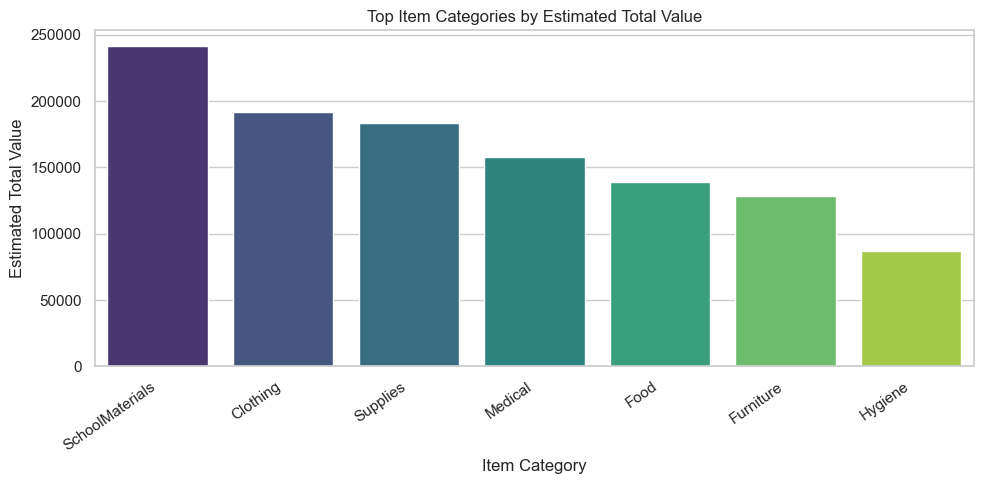

,item_category,total_quantity,total_estimated_value,avg_unit_value,unique_items
5,SchoolMaterials,341,241283.72,643.190909,8
0,Clothing,347,191931.84,555.693500,9
6,Supplies,347,183295.66,581.390000,8
4,Medical,321,157636.08,497.742000,9
1,Food,247,139300.10,588.756000,7
2,Furniture,190,128290.01,527.373571,8
3,Hygiene,150,86821.86,595.570000,7


In [6]:
category_summary = (
    df.groupby('item_category', as_index=False)
      .agg(
          total_quantity=('quantity', 'sum'),
          total_estimated_value=('estimated_item_total', 'sum'),
          avg_unit_value=('estimated_unit_value', 'mean'),
          unique_items=('item_name', 'nunique')
      )
      .sort_values('total_estimated_value', ascending=False)
)

plt.figure(figsize=(10, 5))
plot_df = category_summary.head(10)
sns.barplot(data=plot_df, x='item_category', y='total_estimated_value', hue='item_category', palette='viridis', legend=False)
plt.title('Top Item Categories by Estimated Total Value')
plt.xlabel('Item Category')
plt.ylabel('Estimated Total Value')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

category_summary.head(10)

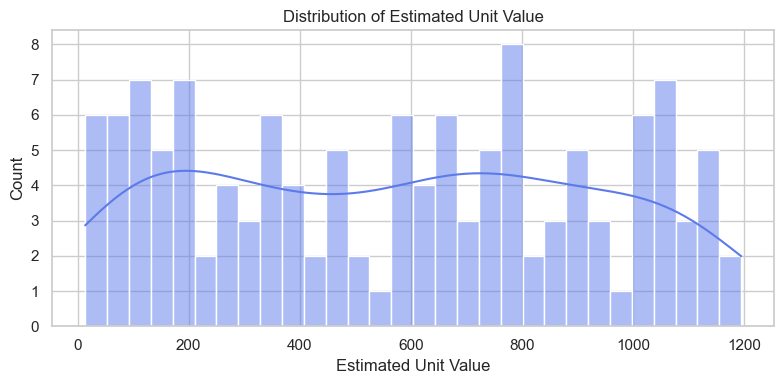

,intended_use,item_count,total_quantity,total_estimated_value
2,Hygiene,26,464,287781.98
1,Health,32,450,221937.64
3,Meals,20,326,215779.22
4,Shelter,22,288,201646.65
0,Education,29,415,201413.78


In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='estimated_unit_value', bins=30, kde=True, color='#5C7AEA')
plt.title('Distribution of Estimated Unit Value')
plt.xlabel('Estimated Unit Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

intended_use_summary = (
    df.groupby('intended_use', as_index=False)
      .agg(
          item_count=('item_id', 'count'),
          total_quantity=('quantity', 'sum'),
          total_estimated_value=('estimated_item_total', 'sum')
      )
      .sort_values('total_estimated_value', ascending=False)
)
intended_use_summary

In [8]:
condition_summary = (
    df.groupby('received_condition', as_index=False)
      .agg(
          item_count=('item_id', 'count'),
          avg_unit_value=('estimated_unit_value', 'mean'),
          total_estimated_value=('estimated_item_total', 'sum')
      )
      .sort_values('item_count', ascending=False)
)
condition_summary

,received_condition,item_count,avg_unit_value,total_estimated_value
2,New,92,559.480978,801133.40
1,Good,28,576.068929,243991.08
0,Fair,9,681.868889,83434.79


In [9]:
# Phase 4: Modeling - Explanatory (interpretable linear model)

explanatory_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

explanatory_model.fit(X_train, y_train)
exp_pred = explanatory_model.predict(X_test)

exp_metrics = {
    'model': 'LinearRegression (explanatory proxy)',
    'MAE': mean_absolute_error(y_test, exp_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, exp_pred)),
    'R2': r2_score(y_test, exp_pred)
}

exp_metrics

{'model': 'LinearRegression (explanatory proxy)',
 'MAE': 2175.739377524432,
 'RMSE': 2873.0430920112512,
 'R2': 0.8747608837989311}

In [10]:
# Phase 4: Modeling - Predictive (nonlinear model)

predictive_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

predictive_model.fit(X_train, y_train)
pred_pred = predictive_model.predict(X_test)

pred_metrics = {
    'model': 'RandomForestRegressor',
    'MAE': mean_absolute_error(y_test, pred_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_pred)),
    'R2': r2_score(y_test, pred_pred)
}

pred_metrics

{'model': 'RandomForestRegressor',
 'MAE': 1218.2752493825972,
 'RMSE': 1773.0591058869668,
 'R2': 0.9523017834511451}

In [11]:
# Phase 5: Evaluation and Selection

cv_scores_linear = cross_val_score(
    explanatory_model, X, y, cv=5, scoring='neg_root_mean_squared_error'
)
cv_scores_rf = cross_val_score(
    predictive_model, X, y, cv=5, scoring='neg_root_mean_squared_error'
)

evaluation_table = pd.DataFrame([
    {
        'model': 'LinearRegression (explanatory)',
        'test_MAE': exp_metrics['MAE'],
        'test_RMSE': exp_metrics['RMSE'],
        'test_R2': exp_metrics['R2'],
        'cv_RMSE_mean': -cv_scores_linear.mean(),
        'cv_RMSE_std': cv_scores_linear.std()
    },
    {
        'model': 'RandomForestRegressor (predictive)',
        'test_MAE': pred_metrics['MAE'],
        'test_RMSE': pred_metrics['RMSE'],
        'test_R2': pred_metrics['R2'],
        'cv_RMSE_mean': -cv_scores_rf.mean(),
        'cv_RMSE_std': cv_scores_rf.std()
    }
]).sort_values('test_RMSE')

evaluation_table

,model,test_MAE,test_RMSE,test_R2,cv_RMSE_mean,cv_RMSE_std
1,RandomForestRegressor (predictive),1218.275249,1773.059106,0.952302,1551.313970,527.287369
0,LinearRegression (explanatory),2175.739378,2873.043092,0.874761,3806.322929,345.041369


In [12]:
# Simple fairness check by received condition (error parity)

test_eval = X_test.copy()
test_eval['actual'] = y_test.values
test_eval['predicted'] = pred_pred
test_eval['abs_error'] = (test_eval['actual'] - test_eval['predicted']).abs()

fairness_report = (
    test_eval.groupby('received_condition', as_index=False)
             .agg(
                 records=('actual', 'count'),
                 mean_actual=('actual', 'mean'),
                 mean_prediction=('predicted', 'mean'),
                 mean_abs_error=('abs_error', 'mean')
             )
             .sort_values('mean_abs_error', ascending=False)
)

fairness_report

,received_condition,records,mean_actual,mean_prediction,mean_abs_error
2,New,20,9604.142,9065.882183,1358.685215
0,Fair,1,4756.200,5586.212190,830.012190
1,Good,5,13763.436,13404.923818,734.287998


In [13]:
# Phase 6: Feature Selection / Feature Impact

# 6a) Interpretable linear coefficients
feature_names = explanatory_model.named_steps['preprocessor'].get_feature_names_out()
linear_coefs = explanatory_model.named_steps['model'].coef_

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': linear_coefs,
    'abs_coefficient': np.abs(linear_coefs)
}).sort_values('abs_coefficient', ascending=False)

# 6b) Predictive feature importance via permutation
perm = permutation_importance(
    predictive_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

perm_table = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

print('Top explanatory features (linear):')
display(coef_table.head(15))

print('Top predictive features (permutation):')
perm_table.head(15)

Top explanatory features (linear):


,feature,coefficient,abs_coefficient
2,num__estimated_unit_value,5480.655996,5480.655996
1,num__quantity,4662.165124,4662.165124
20,cat__unit_of_measure_boxes,-1798.285559,1798.285559
18,cat__item_category_SchoolMaterials,1764.286773,1764.286773
15,cat__item_category_Furniture,1629.582929,1629.582929
12,cat__item_name_Uniforms,1263.243415,1263.243415
17,cat__item_category_Medical,-1204.032288,1204.032288
8,cat__item_name_Hygiene Kits,1094.557012,1094.557012
26,cat__intended_use_Health,1041.840872,1041.840872
19,cat__item_category_Supplies,-985.356589,985.356589


Top predictive features (permutation):


,feature,importance_mean,importance_std
5,estimated_unit_value,7172.005533,1223.191720
3,quantity,4894.791144,1085.018771
8,is_bulk_item,323.278897,188.119998
2,item_category,9.800496,7.444292
1,item_name,6.818769,3.971123
4,unit_of_measure,0.367884,4.852776
7,received_condition,-6.602451,4.330295
6,intended_use,-8.835834,16.037321
0,donation_id,-22.731443,47.591657


## Phase 7: Deployment Plan and Artifacts

Deployment target for this project is the **predictive model** because it is optimized for out-of-sample accuracy.

The deployment package exported below includes:
- Serialized model pipeline (`.joblib`)
- Feature schema (`.json`)
- Top predictive features (`.csv`)
- Fairness error report (`.csv`)

These can be used in a web app endpoint or dashboard where users submit item details and receive estimated item value.

In [14]:
artifacts_dir = Path('../ml-pipelines/artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / 'in_kind_donation_items_predictive_model.joblib'
schema_path = artifacts_dir / 'in_kind_donation_items_model_schema.json'
features_path = artifacts_dir / 'in_kind_donation_items_top_features.csv'
fairness_path = artifacts_dir / 'in_kind_donation_items_fairness_report.csv'

joblib.dump(predictive_model, model_path)

schema = {
    'target': target_col,
    'feature_columns': feature_cols,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'model_type': 'RandomForestRegressor',
    'metrics': {
        'MAE': float(pred_metrics['MAE']),
        'RMSE': float(pred_metrics['RMSE']),
        'R2': float(pred_metrics['R2'])
    }
}

with open(schema_path, 'w', encoding='utf-8') as f:
    json.dump(schema, f, indent=2)

perm_table.head(20).to_csv(features_path, index=False)
fairness_report.to_csv(fairness_path, index=False)

{
    'model_artifact': str(model_path),
    'schema_artifact': str(schema_path),
    'top_features_artifact': str(features_path),
    'fairness_artifact': str(fairness_path)
}

{'model_artifact': '..\\ml-pipelines\\artifacts\\in_kind_donation_items_predictive_model.joblib',
 'schema_artifact': '..\\ml-pipelines\\artifacts\\in_kind_donation_items_model_schema.json',
 'top_features_artifact': '..\\ml-pipelines\\artifacts\\in_kind_donation_items_top_features.csv',
 'fairness_artifact': '..\\ml-pipelines\\artifacts\\in_kind_donation_items_fairness_report.csv'}

## Decision Recommendations (from feature impact + model results)

After running all cells, use the feature-impact outputs to guide decisions:

1. **Prioritize high-impact attributes in intake forms.**
   If `quantity`, `estimated_unit_value`, or specific categories dominate impact, enforce stricter data quality checks for those fields.

2. **Optimize sourcing by intended use and category.**
   Direct outreach to donors for item groups associated with higher estimated value per line item.

3. **Monitor fairness/error by condition groups.**
   If one `received_condition` segment has much higher MAE, investigate data imbalance and add targeted retraining data.

4. **Use explanatory model for policy communication.**
   Coefficients provide directional insight for stakeholders; predictive model should drive automated forecasts.

5. **Retrain periodically.**
   Re-run this notebook monthly/quarterly and compare current metrics against prior saved artifacts.